In [ ]:
# ============================================================
# PRACTICAL 6: DECISION MAKING UNDER UNCERTAINTY
# ============================================================

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [4]:
# ============================================================
# PART A: DEVELOP A DECISION TREE MODEL
# ============================================================

# 1. Load the dataset and display first 10 records
df = pd.read_csv("supermarket_sales.csv")

print("First 10 Records:")
print(df.head(10))

First 10 Records:
    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428      A     Yangon        Member  Female   
1  226-31-3081      C  Naypyitaw        Normal  Female   
2  631-41-3108      A     Yangon        Normal    Male   
3  123-19-1176      A     Yangon        Member    Male   
4  373-73-7910      A     Yangon        Normal    Male   
5  699-14-3026      C  Naypyitaw        Normal    Male   
6  355-53-5943      A     Yangon        Member  Female   
7  315-22-5665      C  Naypyitaw        Normal  Female   
8  665-32-9167      A     Yangon        Member  Female   
9  692-92-5582      B   Mandalay        Member  Female   

             Product line  Unit price  Quantity   Tax 5%     Total       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715   1/5/2019   
1  Electronic accessories       15.28         5   3.8200   80.2200   3/8/2019   
2      Home and lifestyle       46.33         7  16.2155  340.5255   3/3/2019   
3       Health and 

In [5]:
# 2. Display number of records, columns, column names and data types
print("\nNumber of Records:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)


# 3. Display all unique values of product_line
print("\nUnique Product Lines:")
print(df["Product line"].unique())


Number of Records: 1000
Number of Columns: 17

Column Names:
['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date', 'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income', 'Rating']

Data Types:
Invoice ID                     str
Branch                         str
City                           str
Customer type                  str
Gender                         str
Product line                   str
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Total                      float64
Date                           str
Time                           str
Payment                        str
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object

Unique Product Lines:
<StringArray>
[     'Health and beauty', 'Electronic accessories',     'Home and lif

In [6]:
# ============================================================
# 4. Calculate total revenue for each product line
# ============================================================

total_revenue = df.groupby("Product line")["Total"].sum()

print("\nTotal Revenue by Product Line:")
print(total_revenue)



Total Revenue by Product Line:
Product line
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Food and beverages        56144.8440
Health and beauty         49193.7390
Home and lifestyle        53861.9130
Sports and travel         55122.8265
Name: Total, dtype: float64


In [7]:
# ============================================================
# 5. Calculate average revenue for each product line
# ============================================================

average_revenue = df.groupby("Product line")["Total"].mean()

print("\nAverage Revenue by Product Line:")
print(average_revenue)


Average Revenue by Product Line:
Product line
Electronic accessories    319.632538
Fashion accessories       305.089298
Food and beverages        322.671517
Health and beauty         323.643020
Home and lifestyle        336.636956
Sports and travel         332.065220
Name: Total, dtype: float64


In [8]:
# ============================================================
# 6. Calculate total quantity sold for each product line
# ============================================================

total_quantity = df.groupby("Product line")["Quantity"].sum()

print("\nTotal Quantity Sold by Product Line:")
print(total_quantity)



Total Quantity Sold by Product Line:
Product line
Electronic accessories    971
Fashion accessories       902
Food and beverages        952
Health and beauty         854
Home and lifestyle        911
Sports and travel         920
Name: Quantity, dtype: int64


In [9]:
# ============================================================
# 7. Calculate median value of revenue column
# ============================================================

median_revenue = df["Total"].median()

print("\nMedian Revenue:", median_revenue)



Median Revenue: 253.848


In [10]:
# ============================================================
# 8 & 9. Classify transactions as High Revenue or Low Revenue
# and create revenue_level column
# ============================================================

df["revenue_level"] = np.where(
    df["Total"] >= median_revenue,
    "High Revenue",
    "Low Revenue"
)

print("\nRevenue Classification:")
print(df[["Product line", "Total", "revenue_level"]].head(10))


Revenue Classification:
             Product line     Total revenue_level
0       Health and beauty  548.9715  High Revenue
1  Electronic accessories   80.2200   Low Revenue
2      Home and lifestyle  340.5255  High Revenue
3       Health and beauty  489.0480  High Revenue
4       Sports and travel  634.3785  High Revenue
5  Electronic accessories  627.6165  High Revenue
6  Electronic accessories  433.6920  High Revenue
7      Home and lifestyle  772.3800  High Revenue
8       Health and beauty   76.1460   Low Revenue
9      Food and beverages  172.7460   Low Revenue


In [11]:
# ============================================================
# 10. Number of High and Low Revenue transactions
# for each product line
# ============================================================

revenue_counts = pd.crosstab(
    df["Product line"],
    df["revenue_level"]
)

print("\nHigh and Low Revenue Transactions:")
print(revenue_counts)


High and Low Revenue Transactions:
revenue_level           High Revenue  Low Revenue
Product line                                     
Electronic accessories            79           91
Fashion accessories               84           94
Food and beverages                86           88
Health and beauty                 81           71
Home and lifestyle                82           78
Sports and travel                 88           78


In [12]:
# ============================================================
# 11. Calculate probability of High and Low Revenue
# for each product line
# ============================================================

revenue_probability = pd.crosstab(
    df["Product line"],
    df["revenue_level"],
    normalize="index"
)

print("\nRevenue Probabilities:")
print(revenue_probability)


Revenue Probabilities:
revenue_level           High Revenue  Low Revenue
Product line                                     
Electronic accessories      0.464706     0.535294
Fashion accessories         0.471910     0.528090
Food and beverages          0.494253     0.505747
Health and beauty           0.532895     0.467105
Home and lifestyle          0.512500     0.487500
Sports and travel           0.530120     0.469880


In [13]:
# ============================================================
# 12. Verify probabilities add up to 1
# ============================================================

print("\nProbability Sum:")
print(revenue_probability.sum(axis=1))


Probability Sum:
Product line
Electronic accessories    1.0
Fashion accessories       1.0
Food and beverages        1.0
Health and beauty         1.0
Home and lifestyle        1.0
Sports and travel         1.0
dtype: float64


In [14]:
# ============================================================
# 13. Average revenue for High and Low Revenue
# for each product line
# ============================================================

average_payoff = df.groupby(
    ["Product line", "revenue_level"]
)["Total"].mean()

print("\nAverage Revenue / Payoff:")
print(average_payoff)



Average Revenue / Payoff:
Product line            revenue_level
Electronic accessories  High Revenue     537.006152
                        Low Revenue      130.923577
Fashion accessories     High Revenue     512.329375
                        Low Revenue      119.896037
Food and beverages      High Revenue     515.127680
                        Low Revenue      134.589358
Health and beauty       High Revenue     497.221407
                        Low Revenue      125.616972
Home and lifestyle      High Revenue     529.582738
                        Low Revenue      133.796519
Sports and travel       High Revenue     518.546438
                        Low Revenue      121.676154
Name: Total, dtype: float64


In [15]:
# ============================================================
# 14. Create DataFrame containing:
# Product Line, Revenue Level, Probability and Payoff
# ============================================================

decision_data = []

for product in df["Product line"].unique():

    for level in ["High Revenue", "Low Revenue"]:

        probability = revenue_probability.loc[product].get(level, 0)

        if (product, level) in average_payoff.index:
            payoff = average_payoff.loc[(product, level)]
        else:
            payoff = 0

        decision_data.append([
            product,
            level,
            probability,
            payoff
        ])


decision_df = pd.DataFrame(
    decision_data,
    columns=[
        "Product Line",
        "Revenue Level",
        "Probability",
        "Payoff"
    ]
)

print("\nDecision DataFrame:")
print(decision_df)



Decision DataFrame:
              Product Line Revenue Level  Probability      Payoff
0        Health and beauty  High Revenue     0.532895  497.221407
1        Health and beauty   Low Revenue     0.467105  125.616972
2   Electronic accessories  High Revenue     0.464706  537.006152
3   Electronic accessories   Low Revenue     0.535294  130.923577
4       Home and lifestyle  High Revenue     0.512500  529.582738
5       Home and lifestyle   Low Revenue     0.487500  133.796519
6        Sports and travel  High Revenue     0.530120  518.546438
7        Sports and travel   Low Revenue     0.469880  121.676154
8       Food and beverages  High Revenue     0.494253  515.127680
9       Food and beverages   Low Revenue     0.505747  134.589358
10     Fashion accessories  High Revenue     0.471910  512.329375
11     Fashion accessories   Low Revenue     0.528090  119.896037


In [16]:
# ============================================================
# 15. Identify decision alternatives and uncertain outcomes
# ============================================================

decision_alternatives = df["Product line"].unique()

uncertain_outcomes = [
    "High Revenue",
    "Low Revenue"
]

print("\nDecision Alternatives:")
print(decision_alternatives)

print("\nUncertain Outcomes:")
print(uncertain_outcomes)



Decision Alternatives:
<StringArray>
[     'Health and beauty', 'Electronic accessories',     'Home and lifestyle',
      'Sports and travel',     'Food and beverages',    'Fashion accessories']
Length: 6, dtype: str

Uncertain Outcomes:
['High Revenue', 'Low Revenue']


In [17]:
# ============================================================
# 16 & 17. Construct and display Decision Tree
# ============================================================

print("\n================ DECISION TREE ================")

for product in decision_alternatives:

    print("\n", product)

    product_data = decision_df[
        decision_df["Product Line"] == product
    ]

    for _, row in product_data.iterrows():

        print(
            "   ├──",
            row["Revenue Level"],
            "| Probability =",
            round(row["Probability"], 3),
            "| Payoff =",
            round(row["Payoff"], 2)
        )



================ DECISION TREE ================

 Health and beauty
   ├── High Revenue | Probability = 0.533 | Payoff = 497.22
   ├── Low Revenue | Probability = 0.467 | Payoff = 125.62

 Electronic accessories
   ├── High Revenue | Probability = 0.465 | Payoff = 537.01
   ├── Low Revenue | Probability = 0.535 | Payoff = 130.92

 Home and lifestyle
   ├── High Revenue | Probability = 0.512 | Payoff = 529.58
   ├── Low Revenue | Probability = 0.487 | Payoff = 133.8

 Sports and travel
   ├── High Revenue | Probability = 0.53 | Payoff = 518.55
   ├── Low Revenue | Probability = 0.47 | Payoff = 121.68

 Food and beverages
   ├── High Revenue | Probability = 0.494 | Payoff = 515.13
   ├── Low Revenue | Probability = 0.506 | Payoff = 134.59

 Fashion accessories
   ├── High Revenue | Probability = 0.472 | Payoff = 512.33
   ├── Low Revenue | Probability = 0.528 | Payoff = 119.9


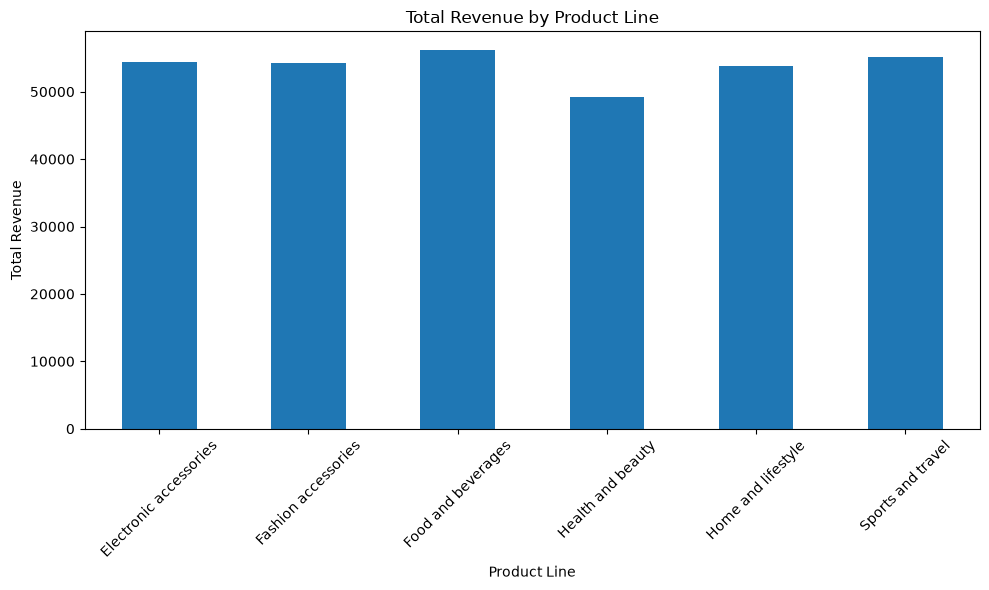

In [18]:
# ============================================================
# 18. Visualization of Total Revenue
# ============================================================

plt.figure(figsize=(10, 6))

total_revenue.plot(kind="bar")

plt.title("Total Revenue by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

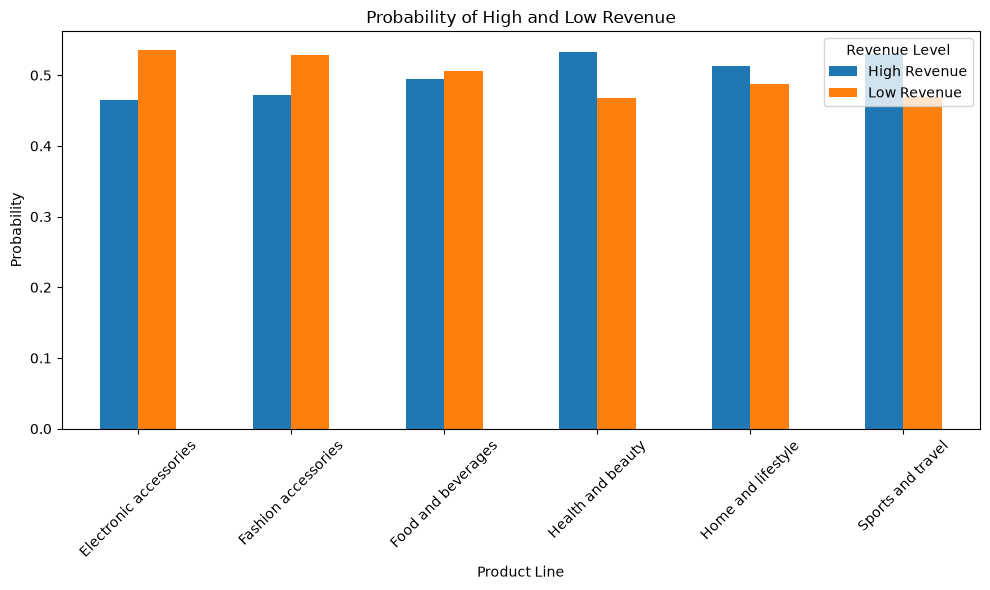

In [19]:
# ============================================================
# 19. Visualization of High and Low Revenue Probability
# ============================================================

revenue_probability.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Probability of High and Low Revenue")
plt.xlabel("Product Line")
plt.ylabel("Probability")
plt.xticks(rotation=45)
plt.legend(title="Revenue Level")
plt.tight_layout()
plt.show()


In [20]:
# ============================================================
# 20. Product line with highest probability of High Revenue
# ============================================================

high_probability = revenue_probability["High Revenue"]

highest_probability_product = high_probability.idxmax()

print(
    "\nProduct Line with Highest Probability of High Revenue:",
    highest_probability_product
)

print(
    "Probability:",
    high_probability.max()
)


Product Line with Highest Probability of High Revenue: Health and beauty
Probability: 0.5328947368421053


In [21]:
# ============================================================
# PART B: APPLY EXPECTED VALUE
# ============================================================

# 21. Expected Value Explanation
print("\nExpected Value helps us select the product line")
print("that provides the highest expected payoff.")


Expected Value helps us select the product line
that provides the highest expected payoff.


In [22]:
# ============================================================
# 22. Mathematical Formula
# ============================================================

print("\nExpected Value Formula:")
print("EV = Sum of (Probability × Payoff)")



Expected Value Formula:
EV = Sum of (Probability × Payoff)


In [ ]:
# ============================================================
# 23. Calculate Expected Value of one product line
# ============================================================

one_product = decision_alternatives[0]
one_product_data = decision_df[
    decision_df["Product Line"] == one_product
]
expected_value_one = (
    one_product_data["Probability"] *
    one_product_data["Payoff"]
).sum()
print(
    "\nExpected Value of",
    one_product,
    "=",
    expected_value_one
)



Expected Value of Health and beauty = 323.6430197368422


In [ ]:
# ============================================================
# 24. Calculate Expected Value for every product line
# ============================================================

expected_values = (
    decision_df.assign(
        Expected_Value=
        decision_df["Probability"] *
        decision_df["Payoff"]
    )
    .groupby("Product Line")["Expected_Value"]
    .sum()
)
print("\nExpected Value of Every Product Line:")
print(expected_values)



Expected Value of Every Product Line:
Product Line
Electronic accessories    319.632538
Fashion accessories       305.089298
Food and beverages        322.671517
Health and beauty         323.643020
Home and lifestyle        336.636956
Sports and travel         332.065220
Name: Expected_Value, dtype: float64


In [ ]:
# ============================================================
# 25. Create Expected Value DataFrame
# ============================================================

ev_data = []
for product in decision_alternatives:
    high_prob = revenue_probability.loc[product].get(
        "High Revenue", 0
    )
    low_prob = revenue_probability.loc[product].get(
        "Low Revenue", 0
    )
    high_payoff = average_payoff.get(
        (product, "High Revenue"), 0
    )
    low_payoff = average_payoff.get(
        (product, "Low Revenue"), 0
    )
    ev = (
        high_prob * high_payoff
        +
        low_prob * low_payoff
    )
    ev_data.append([
        product,
        high_prob,
        high_payoff,
        low_prob,
        low_payoff,
        ev
    ])
ev_df = pd.DataFrame(
    ev_data,
    columns=[
        "Product Line",
        "High Revenue Probability",
        "High Revenue Payoff",
        "Low Revenue Probability",
        "Low Revenue Payoff",
        "Expected Value"
    ]
)
print("\nExpected Value DataFrame:")
print(ev_df)



Expected Value DataFrame:
             Product Line  High Revenue Probability  High Revenue Payoff  \
0       Health and beauty                  0.532895           497.221407   
1  Electronic accessories                  0.464706           537.006152   
2      Home and lifestyle                  0.512500           529.582738   
3       Sports and travel                  0.530120           518.546438   
4      Food and beverages                  0.494253           515.127680   
5     Fashion accessories                  0.471910           512.329375   

   Low Revenue Probability  Low Revenue Payoff  Expected Value  
0                 0.467105          125.616972      323.643020  
1                 0.535294          130.923577      319.632538  
2                 0.487500          133.796519      336.636956  
3                 0.469880          121.676154      332.065220  
4                 0.505747          134.589358      322.671517  
5                 0.528090          119.896037    

In [26]:
# ============================================================
# 26. Compare Expected Values
# ============================================================

print("\nExpected Value Comparison:")
print(
    ev_df[
        ["Product Line", "Expected Value"]
    ].sort_values(
        by="Expected Value",
        ascending=False
    )
)


Expected Value Comparison:
             Product Line  Expected Value
2      Home and lifestyle      336.636956
3       Sports and travel      332.065220
0       Health and beauty      323.643020
4      Food and beverages      322.671517
1  Electronic accessories      319.632538
5     Fashion accessories      305.089298


In [ ]:
# ============================================================
# 27. Highest Expected Value
# ============================================================

highest_ev_product = ev_df.loc[
    ev_df["Expected Value"].idxmax(),
    "Product Line"
]
highest_ev = ev_df["Expected Value"].max()
print("\nHighest Expected Value Product Line:")
print(highest_ev_product)
print("Expected Value:", highest_ev)



Highest Expected Value Product Line:
Home and lifestyle
Expected Value: 336.63695625


In [ ]:
# ============================================================
# 28. Lowest Expected Value
# ============================================================

lowest_ev_product = ev_df.loc[
    ev_df["Expected Value"].idxmin(),
    "Product Line"
]
lowest_ev = ev_df["Expected Value"].min()
print("\nLowest Expected Value Product Line:")
print(lowest_ev_product)
print("Expected Value:", lowest_ev)



Lowest Expected Value Product Line:
Fashion accessories
Expected Value: 305.089297752809


In [ ]:
# ============================================================
# 29. Rank product lines
# ============================================================

ranking = ev_df[
    ["Product Line", "Expected Value"]
].sort_values(
    by="Expected Value",
    ascending=False
)
ranking["Rank"] = range(1, len(ranking) + 1)
print("\nProduct Line Ranking:")
print(ranking)



Product Line Ranking:
             Product Line  Expected Value  Rank
2      Home and lifestyle      336.636956     1
3       Sports and travel      332.065220     2
0       Health and beauty      323.643020     3
4      Food and beverages      322.671517     4
1  Electronic accessories      319.632538     5
5     Fashion accessories      305.089298     6


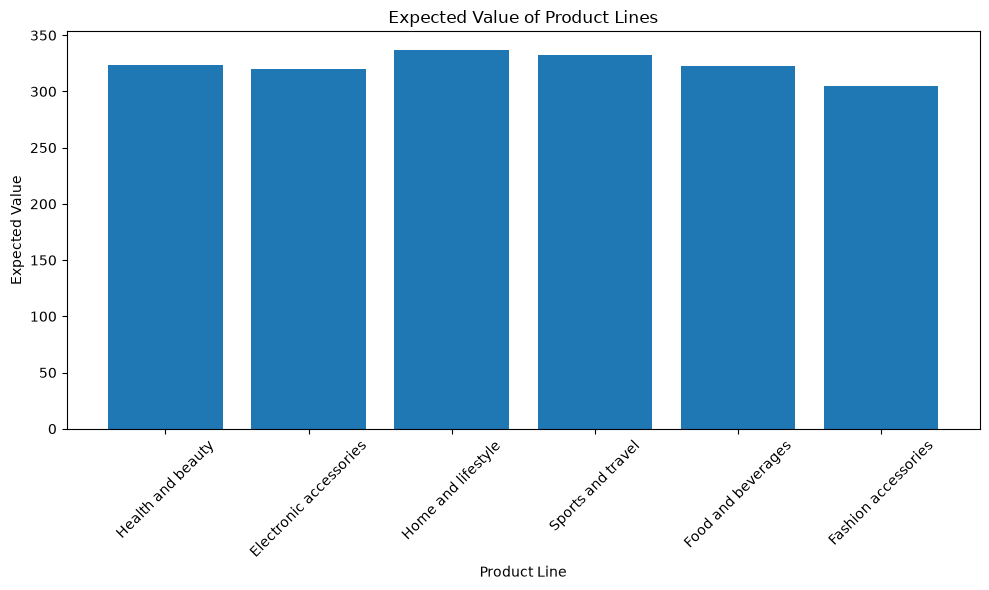

In [ ]:
# ============================================================
# 30. Bar Chart of Expected Values
# ============================================================

plt.figure(figsize=(10, 6))
plt.bar(
    ev_df["Product Line"],
    ev_df["Expected Value"]
)
plt.title("Expected Value of Product Lines")
plt.xlabel("Product Line")
plt.ylabel("Expected Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 31. Compare highest probability with highest EV
# ============================================================

print(
    "\nHighest Probability of High Revenue:",
    highest_probability_product
)
print(
    "Highest Expected Value:",
    highest_ev_product
)



Highest Probability of High Revenue: Health and beauty
Highest Expected Value: Home and lifestyle


In [ ]:
# ============================================================
# 32. Check whether both are same
# ============================================================

if highest_probability_product == highest_ev_product:
    print(
        "\nYes, both are the same product line."
    )
else:
    print(
        "\nNo, they are different product lines."
    )


No, they are different product lines.


In [ ]:
# ============================================================
# 33. Change probability and recalculate EV
# ============================================================

modified_high_probability = 0.70
modified_low_probability = 0.30
product = one_product
high_payoff = average_payoff.get(
    (product, "High Revenue"), 0
)
low_payoff = average_payoff.get(
    (product, "Low Revenue"), 0
)
modified_ev_probability = (
    modified_high_probability * high_payoff
    +
    modified_low_probability * low_payoff
)
print("\nModified Probability:")
print("High Revenue Probability =", modified_high_probability)
print("Low Revenue Probability =", modified_low_probability)
print("New Expected Value =", modified_ev_probability)



Modified Probability:
High Revenue Probability = 0.7
Low Revenue Probability = 0.3
New Expected Value = 385.7400767344809


In [ ]:
# ============================================================
# 34. Change payoff and recalculate EV
# ============================================================

modified_high_payoff = high_payoff * 1.10
modified_ev_payoff = (
    high_probability.loc[product] * modified_high_payoff
    +
    revenue_probability.loc[product].get("Low Revenue", 0)
    * low_payoff
)
print("\nModified High Revenue Payoff:")
print(modified_high_payoff)
print("New Expected Value:", modified_ev_payoff)



Modified High Revenue Payoff:
546.9435481481482
New Expected Value: 350.1396868421054


In [ ]:
# ============================================================
# 35. Automatically calculate EV and select best product
# ============================================================

best_product = ev_df.loc[
    ev_df["Expected Value"].idxmax()
]
print("\n========== AUTOMATIC DECISION ==========")
print(
    "Best Product Line:",
    best_product["Product Line"]
)
print(
    "Highest Expected Value:",
    best_product["Expected Value"]
)


========== AUTOMATIC DECISION ==========
Best Product Line: Home and lifestyle
Highest Expected Value: 336.63695625


In [ ]:
# ============================================================
# 36. Display final decision tree with Expected Value
# ============================================================

print("\n========== FINAL DECISION TREE ==========")
for product in decision_alternatives:
    product_ev = ev_df.loc[
        ev_df["Product Line"] == product,
        "Expected Value"
    ].iloc[0]
    print("\n", product)
    print("   Expected Value =", round(product_ev, 2))
    product_data = decision_df[
        decision_df["Product Line"] == product
    ]
    for _, row in product_data.iterrows():
        print(
            "   ├──",
            row["Revenue Level"],
            "→ Probability:",
            round(row["Probability"], 3),
            "Payoff:",
            round(row["Payoff"], 2)
        )



========== FINAL DECISION TREE ==========

 Health and beauty
   Expected Value = 323.64
   ├── High Revenue → Probability: 0.533 Payoff: 497.22
   ├── Low Revenue → Probability: 0.467 Payoff: 125.62

 Electronic accessories
   Expected Value = 319.63
   ├── High Revenue → Probability: 0.465 Payoff: 537.01
   ├── Low Revenue → Probability: 0.535 Payoff: 130.92

 Home and lifestyle
   Expected Value = 336.64
   ├── High Revenue → Probability: 0.512 Payoff: 529.58
   ├── Low Revenue → Probability: 0.487 Payoff: 133.8

 Sports and travel
   Expected Value = 332.07
   ├── High Revenue → Probability: 0.53 Payoff: 518.55
   ├── Low Revenue → Probability: 0.47 Payoff: 121.68

 Food and beverages
   Expected Value = 322.67
   ├── High Revenue → Probability: 0.494 Payoff: 515.13
   ├── Low Revenue → Probability: 0.506 Payoff: 134.59

 Fashion accessories
   Expected Value = 305.09
   ├── High Revenue → Probability: 0.472 Payoff: 512.33
   ├── Low Revenue → Probability: 0.528 Payoff: 119.9


In [ ]:
# ============================================================
# 37. Final Business Recommendation
# ============================================================

print("\n========== BUSINESS RECOMMENDATION ==========")
print(
    "The business should select",
    highest_ev_product,
    "because it has the highest Expected Value of",
    round(highest_ev, 2)
)
print(
    "This means it provides the best expected financial outcome"
    " among all product lines."
)


========== BUSINESS RECOMMENDATION ==========
The business should select Home and lifestyle because it has the highest Expected Value of 336.64
This means it provides the best expected financial outcome among all product lines.
